# ECS7037P Lab 01: Introduction to Neural Networks

In this notebook, we will build a perceptron from scratch and use it to solve simple classification problems. Along the way, you will learn several core concepts and tools used in neural networks.

Before we begin, here are some key terms you should know:

1. **Jupyter Notebook:** An interactive environment where you can write code, add notes, and display results in one document. It is ideal for learning because you can run code one cell at a time and immediately see the output.

2. **Google Colab:** Google Colab is a cloud-based platform that lets you run Jupyter Notebooks in your browser without installing anything. It also provides free access to GPUs.

3. **GPU (Graphics Processing Unit)**: GPU is a processor designed to perform many calculations in parallel. Because neural networks involve a large number of mathematical operations, GPUs can significantly speed up training.

**No submission is required for this lab**

---

Before continuing, make sure you have opened this .ipynb file in Google Colab and successfully connected to a runtime by clicking “Connect” in the top-right corner.

Tutorial on how to open Jupyter Notebook in Google Colab: https://www.youtube.com/watch?v=R3sKKvMCwTo

## Building a Perceptron from Scratch

We have learned what is a perceptron in the lecture, let's implement a simple perceptron using only basic Python. The perceptron is a fundamental building block of neural networks and is used for binary classification tasks.

We will:
- Define the perceptron model
- Train it on a simple dataset
- Test its predictions

In [1]:
# Simple Perceptron from Scratch

# 1. Define the perceptron structure
input_size = 2  # Number of inputs (for a 2-input logic gate)
weights = [0.0, 0.0, 0.0]  # [w1, w2, bias]
learning_rate = 1.0

def predict(inputs, weights):
    # Weighted sum + bias
    total = weights[0] * inputs[0] + weights[1] * inputs[1] + weights[2]
    return 1 if total >= 0 else 0

# 2. Training data
X = [[0, 0], [0, 1], [1, 0], [1, 1]]
y = [0, 0, 0, 1]

# Train for 10 epochs
for epoch in range(10):
    for xi, target in zip(X, y):
        output = predict(xi, weights)
        error = target - output

        # Perceptron update rule
        weights[0] += learning_rate * error * xi[0]
        weights[1] += learning_rate * error * xi[1]
        weights[2] += learning_rate * error  # bias update

# 3. Evaluate predictions
# we will evaluate on the same input set for simplicity, in real ML problems, always keep a separate test set.
print("Trained weights:", weights)
correct = 0
for xi, target in zip(X, y):
    pred = predict(xi, weights)
    print(f"Input: {xi}, Target: {target}, Predicted: {pred}")
    if pred == target:
        correct += 1

accuracy = correct / len(X)
print(f"Accuracy on evaluation set: {accuracy:.2f}")

Trained weights: [2.0, 1.0, -3.0]
Input: [0, 0], Target: 0, Predicted: 0
Input: [0, 1], Target: 0, Predicted: 0
Input: [1, 0], Target: 0, Predicted: 0
Input: [1, 1], Target: 1, Predicted: 1
Accuracy on evaluation set: 1.00


### Exercise 1:
1. Look at the four points
2. Use the trained weights you get
3. Sketch by hand where you think the decision boundary should be.
4. Run the next cell to compare your sketch with the actual boundary.

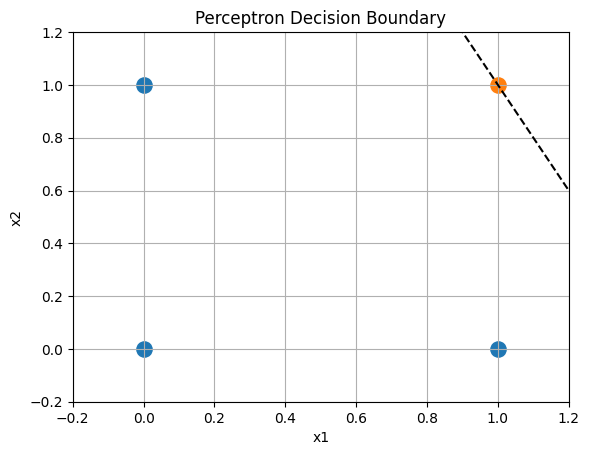

In [2]:
# Let's visualization the perceptron decision boundary, you don't need to understand the code below, just run it to see the plot.
import matplotlib.pyplot as plt

# Plot points: blue = class 0, orange = class 1
for point, label in zip(X, y):
    color = "tab:blue" if label == 0 else "tab:orange"
    plt.scatter(point[0], point[1], color=color, s=120)

# Decision boundary: w1*x1 + w2*x2 + b = 0
w1, w2, b = weights
x_vals = [-0.2, 1.2]
if w2 != 0:
    y_vals = [-(w1 * x + b) / w2 for x in x_vals]
    plt.plot(x_vals, y_vals, "k--")

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Perceptron Decision Boundary")
plt.grid(True)
plt.show()

### Exercise 2:
The perceptron we implemented is an AND logic gate. Can you think about why this works?

Now modify the same perceptron code to learn different logic gates:

1. Keep `X = [[0,0], [0,1], [1,0], [1,1]]` the same
2. Change only the target labels `y`
- **OR gate**: `y = [0, 1, 1, 1]`
- **NAND gate**: `y = [1, 1, 1, 0]`
3. Re-run training, prediction, and visualization.

Then answer:

- Did the perceptron learn both gates correctly?
- How did the final weights change?
- How did the decision boundary change?



OR gate
Trained weights: [1.0, 1.0, -1.0]
Input: [0, 0], Target: 0, Predicted: 0
Input: [0, 1], Target: 1, Predicted: 1
Input: [1, 0], Target: 1, Predicted: 1
Input: [1, 1], Target: 1, Predicted: 1
Accuracy: 1.00

NAND gate
Trained weights: [-2.0, -1.0, 2.0]
Input: [0, 0], Target: 1, Predicted: 1
Input: [0, 1], Target: 1, Predicted: 1
Input: [1, 0], Target: 1, Predicted: 1
Input: [1, 1], Target: 0, Predicted: 0
Accuracy: 1.00


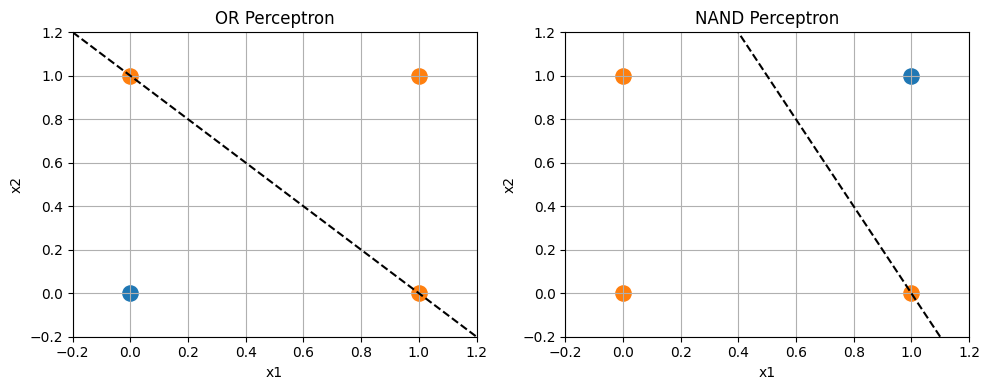

In [3]:
# Exercise 2: Learn OR and NAND gates
# We keep X the same and change only the target labels y.

import matplotlib.pyplot as plt

X = [[0, 0], [0, 1], [1, 0], [1, 1]]
learning_rate = 1.0
epochs = 10

def train_perceptron(X, y, epochs=10, learning_rate=1.0):
    weights = [0.0, 0.0, 0.0]  # [w1, w2, bias]

    for epoch in range(epochs):
        for xi, target in zip(X, y):
            output = predict(xi, weights)
            error = target - output

            weights[0] += learning_rate * error * xi[0]
            weights[1] += learning_rate * error * xi[1]
            weights[2] += learning_rate * error

    return weights

def evaluate_gate(name, y):
    gate_weights = train_perceptron(X, y, epochs=epochs, learning_rate=learning_rate)

    print(f"\n{name} gate")
    print("Trained weights:", gate_weights)

    correct = 0
    for xi, target in zip(X, y):
        pred = predict(xi, gate_weights)
        print(f"Input: {xi}, Target: {target}, Predicted: {pred}")
        correct += int(pred == target)

    accuracy = correct / len(X)
    print(f"Accuracy: {accuracy:.2f}")
    return gate_weights

or_y = [0, 1, 1, 1]
nand_y = [1, 1, 1, 0]

or_weights = evaluate_gate("OR", or_y)
nand_weights = evaluate_gate("NAND", nand_y)

# Visualise both learned decision boundaries.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, name, labels, gate_weights in [
    (axes[0], "OR", or_y, or_weights),
    (axes[1], "NAND", nand_y, nand_weights),
]:
    for point, label in zip(X, labels):
        color = "tab:blue" if label == 0 else "tab:orange"
        ax.scatter(point[0], point[1], color=color, s=120)

    w1, w2, b = gate_weights
    x_vals = [-0.2, 1.2]

    if w2 != 0:
        y_vals = [-(w1 * x + b) / w2 for x in x_vals]
        ax.plot(x_vals, y_vals, "k--")

    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(f"{name} Perceptron")
    ax.grid(True)

plt.tight_layout()
plt.show()


In [4]:
# Exercise 3: Compare different numbers of training epochs

X = [[0, 0], [0, 1], [1, 0], [1, 1]]
y = [0, 0, 0, 1]

epoch_values = [1, 3, 10, 30]

for num_epochs in epoch_values:
    epoch_weights = train_perceptron(X, y, epochs=num_epochs, learning_rate=1.0)
    predictions = [predict(xi, epoch_weights) for xi in X]
    accuracy = sum(pred == target for pred, target in zip(predictions, y)) / len(y)

    print(f"Epochs: {num_epochs}")
    print(f"Final weights: {epoch_weights}")
    print(f"Predictions: {predictions}")
    print(f"Accuracy: {accuracy:.2f}")
    print("-" * 50)


Epochs: 1
Final weights: [1.0, 1.0, 0.0]
Predictions: [1, 1, 1, 1]
Accuracy: 0.25
--------------------------------------------------
Epochs: 3
Final weights: [2.0, 1.0, -2.0]
Predictions: [0, 0, 1, 1]
Accuracy: 0.75
--------------------------------------------------
Epochs: 10
Final weights: [2.0, 1.0, -3.0]
Predictions: [0, 0, 0, 1]
Accuracy: 1.00
--------------------------------------------------
Epochs: 30
Final weights: [2.0, 1.0, -3.0]
Predictions: [0, 0, 0, 1]
Accuracy: 1.00
--------------------------------------------------


In [5]:
# Exercise 4: Keep feature weights fixed and change only the bias

# These feature weights are kept fixed so that only the bias changes.
feature_weights = [1.0, 1.0]
bias_values = [-2.0, -1.0, 0.0, 1.0, 2.0]

X = [[0, 0], [0, 1], [1, 0], [1, 1]]

for bias in bias_values:
    fixed_weights = [feature_weights[0], feature_weights[1], bias]
    predictions = [predict(xi, fixed_weights) for xi in X]

    print(f"Bias: {bias:+.1f} -> Predictions: {predictions}")


Bias: -2.0 -> Predictions: [0, 0, 0, 1]
Bias: -1.0 -> Predictions: [0, 1, 1, 1]
Bias: +0.0 -> Predictions: [1, 1, 1, 1]
Bias: +1.0 -> Predictions: [1, 1, 1, 1]
Bias: +2.0 -> Predictions: [1, 1, 1, 1]


In [6]:
# Exercise 5: Train a single perceptron on XOR labels

X = [[0, 0], [0, 1], [1, 0], [1, 1]]
y = [0, 1, 1, 0]

xor_weights = train_perceptron(X, y, epochs=20, learning_rate=1.0)
xor_predictions = [predict(xi, xor_weights) for xi in X]
xor_accuracy = sum(pred == target for pred, target in zip(xor_predictions, y)) / len(y)

print("XOR weights:", xor_weights)
print("XOR predictions:", xor_predictions)
print(f"XOR accuracy: {xor_accuracy:.2f}")
print("A single perceptron cannot perfectly learn XOR because XOR is not linearly separable.")


XOR weights: [-1.0, 0.0, 0.0]
XOR predictions: [1, 1, 0, 0]
XOR accuracy: 0.50
A single perceptron cannot perfectly learn XOR because XOR is not linearly separable.



### Exercise 3:
Train the same perceptron with different epoch values (for example: 1, 3, 10, 30).

1. Compare final weights.
2. Compare predictions and accuracy.
3. Identify when training becomes stable.



### Exercise 4:
keep feature weights fixed and change only the bias.

1. Try several bias values (negative to positive), for example: -2.0, -1.0, 0.0, 1.0, 2.0
2. Observe how predictions change.
3. Explain how bias moves the decision boundary.



### Exercise 5:
Train the same single perceptron on XOR labels:
- `X = [[0,0], [0,1], [1,0], [1,1]]`
- `y = [0, 1, 1, 0]`

Then answer:
1. What accuracy do you get?
2. Why does a single perceptron fail on XOR?



---

## Tensor
In the first part of this lab, we implemented a perceptron using basic Python. This helped us understand how a neural network works. However, as neural networks become larger and more complex, writing everything from scratch becomes tedious and error-prone.

Fortunately, there are powerful libraries that make this much easier. In this course, we will use **PyTorch**, one of the most popular libraries for building and training neural networks.

PyTorch provides tools for:

- Processing data using tensors (multi-dimensional arrays)
- Defining neural network models
- Training models efficiently on CPUs and GPUs


By the end of this course, you should feel comfortable using PyTorch to build and train neural networks. For now, we will focus on the most basic PyTorch concept **tensors**.

**Tensors**:
Tensors are the basic data structure in PyTorch. The class `Tensor` in PyTorch is similar to the class `ndarray` in Numpy. However, it also enables GPU acceleration and automatic differentiation. PyTorch uses tensors to store data, model parameters, and outputs.
- A rank 0 tensor corresponds to a *number*.
- A rank 1 tensor corresponds to a *vector*.
- A rank 2 tensor corresponds to a *matrix*.
- Tensors of higher rank do not have special names.



In [7]:
# Import libraries
import torch
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0+cpu


### Creating Tensors
Let’s use a simple example to see how tensors are created. Suppose we have data for several students, and for each student we want to record: the exam score and [hours_slept, hours_studied].

In [8]:
# Example 1: Creating a scalar (single number)
score_scalar = torch.tensor(5.0)
print(f"Scalar: {score_scalar}")
print(f"Shape: {score_scalar.shape}")
print()

Scalar: 5.0
Shape: torch.Size([])



In [9]:
# Example 2: Creating a vector (1D tensor)
# Represents one student's data: [hours_slept, hours_studied]
student_1 = torch.tensor([7.0, 5.0])
print(f"Vector (1 student): {student_1}")
print(f"Shape: {student_1.shape}")
print()

Vector (1 student): tensor([7., 5.])
Shape: torch.Size([2])



In [10]:
# Example 3: Creating a matrix (2D tensor)
# Represents 5 students, each with 2 features
students_data = torch.tensor([
    [7.0, 5.0],   # Student 1: slept 7h, studied 5h
    [6.0, 8.0],   # Student 2: slept 6h, studied 8h
    [8.0, 4.0],   # Student 3: slept 8h, studied 4h
    [5.0, 9.0],   # Student 4: slept 5h, studied 9h
    [7.5, 6.5],   # Student 5: slept 7.5h, studied 6.5h
])
print(f"Matrix (5 students, 2 features):")
print(students_data)
print(f"Shape: {students_data.shape}")
print(f"\nInterpretation: {students_data.shape[0]} samples, {students_data.shape[1]} features")

Matrix (5 students, 2 features):
tensor([[7.0000, 5.0000],
        [6.0000, 8.0000],
        [8.0000, 4.0000],
        [5.0000, 9.0000],
        [7.5000, 6.5000]])
Shape: torch.Size([5, 2])

Interpretation: 5 samples, 2 features


In [11]:
# Example 4: Creating a 3D tensor (batch of matrices)
# Represents 2 classes of students, each with 5 students and 2 features
classes_data = torch.tensor([
    [   # Class 1
        [7.0, 5.0],   # Student 1
        [6.0, 8.0],   # Student 2
        [8.0, 4.0],   # Student 3
        [5.0, 9.0],   # Student 4
        [7.5, 6.5],   # Student 5
    ],
    [   # Class 2
        [6.5, 7.0],   # Student 1
        [7.0, 6.0],   # Student 2
        [5.5, 8.0],   # Student 3
        [8.0, 5.0],   # Student 4
        [6.0, 7.5],   # Student 5
    ]
])
print(f"3D Tensor (2 classes, 5 students each, 2 features):")
print(classes_data)
print(f"Shape: {classes_data.shape}")
print(f"\nInterpretation: {classes_data.shape[0]} classes, {classes_data.shape[1]} samples per class, {classes_data.shape[2]} features")

3D Tensor (2 classes, 5 students each, 2 features):
tensor([[[7.0000, 5.0000],
         [6.0000, 8.0000],
         [8.0000, 4.0000],
         [5.0000, 9.0000],
         [7.5000, 6.5000]],

        [[6.5000, 7.0000],
         [7.0000, 6.0000],
         [5.5000, 8.0000],
         [8.0000, 5.0000],
         [6.0000, 7.5000]]])
Shape: torch.Size([2, 5, 2])

Interpretation: 2 classes, 5 samples per class, 2 features


We’ve learned how to create 1D, 2D, and 3D tensors using numbers. The idea is straightforward:
- 1D tensor: a list of numbers
- 2D tensor: a list of lists
- 3D tensor: a list of lists of lists

In general, higher-dimensional tensors are created by nesting lists deeper.

Next, let’s learn how to specify the data type when creating a tensor, and explore other ways to create tensors.

In [12]:
# Create tensors of different data types

# Integer tensor (e.g., number of students)
num_students = torch.tensor(5, dtype=torch.int32)

# Float tensor (e.g., hours slept)
hours_slept = torch.tensor([7.0, 6.0, 8.0, 5.0, 7.5], dtype=torch.float32)

# Boolean tensor (e.g., passed or failed)
passed = torch.tensor([True, False, True, False, True], dtype=torch.bool)

print(f"Integer Tensor (num_students): {num_students}, dtype: {num_students.dtype}")
print(f"Float Tensor (hours_slept): {hours_slept}, dtype: {hours_slept.dtype}")
print(f"Boolean Tensor (passed): {passed}, dtype: {passed.dtype}")

Integer Tensor (num_students): 5, dtype: torch.int32
Float Tensor (hours_slept): tensor([7.0000, 6.0000, 8.0000, 5.0000, 7.5000]), dtype: torch.float32
Boolean Tensor (passed): tensor([ True, False,  True, False,  True]), dtype: torch.bool


In [13]:
# Create tensors using different methods
# Using torch.tensor() to create a tensor from a list
tensor_from_list = torch.tensor([[1, 2], [3, 4]])

# Using torch.zeros() to create a tensor filled with zeros
zeros_tensor = torch.zeros((2, 3))

# Using torch.ones() to create a tensor filled with ones
ones_tensor = torch.ones((3, 2))

# Using torch.rand() to create a tensor with random values between 0 and 1
random_tensor = torch.rand((2, 2))

print(f"Tensor from list:\n{tensor_from_list}\n")
print(f"Zeros tensor:\n{zeros_tensor}\n")
print(f"Ones tensor:\n{ones_tensor}\n")
print(f"Random tensor:\n{random_tensor}\n")

Tensor from list:
tensor([[1, 2],
        [3, 4]])

Zeros tensor:
tensor([[0., 0., 0.],
        [0., 0., 0.]])

Ones tensor:
tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])

Random tensor:
tensor([[0.0039, 0.3121],
        [0.0964, 0.0729]])



#### Exercise 6:
Next are some exercises to help you get familiar with tensors.

In [14]:
x = torch.tensor(10.0)
print(x)

tensor(10.)


In [15]:
x = torch.tensor([3.0, 6.0, 9.0])
print(x)

tensor([3., 6., 9.])


In [16]:
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(x)

tensor([[1., 2.],
        [3., 4.]])


In [17]:
x = torch.zeros((3, 4))
print(x)

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])


In [18]:
x = torch.ones((2, 3))
print(x)

tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [19]:
x = torch.rand((4, 4))
print(x)

tensor([[0.5097, 0.3976, 0.0714, 0.4880],
        [0.4133, 0.2481, 0.8651, 0.2642],
        [0.0737, 0.9018, 0.3045, 0.0801],
        [0.1973, 0.4180, 0.4451, 0.9772]])


In [20]:
x = torch.tensor([True, False, True, False], dtype=torch.bool)
print(x)

tensor([ True, False,  True, False])


In [21]:
x = torch.tensor([[1, 2], [3, 4], [5, 6]])
print("Shape:", x.shape)

Shape: torch.Size([3, 2])


#### Tensor Operations in Data Processing

In many deep learning tasks, we rely on basic vector operations to manipulate and combine data effectively:

- **Scalar Multiplication**  
  Scalar multiplication multiplies every element in a tensor by a constant. This can be useful for normalization or adjusting the magnitude of the data.

- **Addition**  
  Addition combines tensors element-wise. This is often used to merge features or add bias.

- **Matrix Multiplication (`matmul`)**  
  `matmul` performs matrix multiplication between compatible tensors. In deep learning, this is commonly used to apply weights to input features in a layer:
  
  $ Y = XW $
  
  Note: an (m×n) matrix multiplied by an (n×p) matrix results in an (m×p) matrix.

In [22]:
# 1. Scalar Multiplication
students_data = torch.tensor([
    [7.0, 5.0],   # Student 1: slept 7h, studied 5h
    [6.0, 8.0],   # Student 2: slept 6h, studied 8h
    [8.0, 4.0],   # Student 3: slept 8h, studied 4h
])
scaled_data = 2 * students_data
print(scaled_data)
# Every student's hours are scaled uniformly.

tensor([[14., 10.],
        [12., 16.],
        [16.,  8.]])


In [23]:
# 2. Addition
boost = torch.tensor([0.5, 1.0])  # +0.5 sleep, +1 study
adjusted_data = students_data + boost
print(adjusted_data)
# Each student gets extra sleep and study time, this works via broadcasting across all rows.

tensor([[7.5000, 6.0000],
        [6.5000, 9.0000],
        [8.5000, 5.0000]])


In [24]:
# 3. Matrix Multiplication (Weighted Score)
# Now we assign weights to each feature to compute a performance score:
weights = torch.tensor([0.6, 0.4])  # 60% sleep, 40% study
performance_scores = torch.matmul(students_data, weights)
print(performance_scores)
# Each student's score is: score=0.6⋅(sleep)+0.4⋅(study)
# Higher weight on studying → more influence on score.
# Output is one score per student

tensor([6.2000, 6.8000, 6.4000])


#### Exercise 7:
Next are some exercises to help you get familiar with tensor operations.

In [25]:
# Q1: Scale all student data by a factor of 3.
scaled_data = 3 * students_data
print(scaled_data)

# Q2: Add a boost of [1.0, 2.0] to each student's data.
boost = torch.tensor([1.0, 2.0])  # +1.0 sleep, +2.0 study
adjusted_data = students_data + boost
print(adjusted_data)

# Q3: Compute performance scores with new weights: [0.5, 0.5].
weights = torch.tensor([0.5, 0.5])  # 50% sleep, 50% study
performance_scores = torch.matmul(students_data, weights)
print(performance_scores)

tensor([[21., 15.],
        [18., 24.],
        [24., 12.]])
tensor([[ 8.,  7.],
        [ 7., 10.],
        [ 9.,  6.]])
tensor([6., 7., 6.])


#### Tensor Operations: Reshaping

One of the most important operations is **reshaping**. This changes the dimensions without changing the data.

In [26]:
# Reshape a (5, 2) matrix into different shapes
# Use a fresh 5 x 2 tensor here because the previous exercise intentionally
# used a smaller 3 x 2 example.
students_data_5 = torch.tensor([
    [7.0, 5.0],
    [6.0, 8.0],
    [8.0, 4.0],
    [5.0, 9.0],
    [7.5, 6.5],
])

reshaped_flat = students_data_5.reshape(-1)  # Flatten to 1D (10 elements)
print(f"Flattened (1D): {reshaped_flat}")
print(f"Shape: {reshaped_flat.shape}")
print()

reshaped_3d = students_data_5.reshape(5, 2, 1)
print("Reshaped to (5, 2, 1):")
print(reshaped_3d)
print(f"Shape: {reshaped_3d.shape}")
print()

reshaped_auto = students_data_5.reshape(5, -1)
print("Reshaped to (5, -1):")
print(reshaped_auto)
print(f"Shape: {reshaped_auto.shape}")
print()

reshaped_auto2 = students_data_5.reshape(-1, 2)
print("Reshaped to (-1, 2):")
print(reshaped_auto2)
print(f"Shape: {reshaped_auto2.shape}")
print()

reshaped_add_dim = students_data_5.unsqueeze(0)
print("Reshaped to (1, 5, 2):")
print(reshaped_add_dim)
print(f"Shape: {reshaped_add_dim.shape}")
print()

reshaped_remove_dim = reshaped_add_dim.squeeze(0)
print("Reshaped back to (5, 2):")
print(reshaped_remove_dim)
print(f"Shape: {reshaped_remove_dim.shape}")


Flattened (1D): tensor([7.0000, 5.0000, 6.0000, 8.0000, 8.0000, 4.0000, 5.0000, 9.0000, 7.5000,
        6.5000])
Shape: torch.Size([10])

Reshaped to (5, 2, 1):
tensor([[[7.0000],
         [5.0000]],

        [[6.0000],
         [8.0000]],

        [[8.0000],
         [4.0000]],

        [[5.0000],
         [9.0000]],

        [[7.5000],
         [6.5000]]])
Shape: torch.Size([5, 2, 1])

Reshaped to (5, -1):
tensor([[7.0000, 5.0000],
        [6.0000, 8.0000],
        [8.0000, 4.0000],
        [5.0000, 9.0000],
        [7.5000, 6.5000]])
Shape: torch.Size([5, 2])

Reshaped to (-1, 2):
tensor([[7.0000, 5.0000],
        [6.0000, 8.0000],
        [8.0000, 4.0000],
        [5.0000, 9.0000],
        [7.5000, 6.5000]])
Shape: torch.Size([5, 2])

Reshaped to (1, 5, 2):
tensor([[[7.0000, 5.0000],
         [6.0000, 8.0000],
         [8.0000, 4.0000],
         [5.0000, 9.0000],
         [7.5000, 6.5000]]])
Shape: torch.Size([1, 5, 2])

Reshaped back to (5, 2):
tensor([[7.0000, 5.0000],
        [6

#### Exercise 8:

Try the exercises below, fill in the blanks and run each cell.

In [27]:
# Q1: Reshape a tensor with 12 elements into shape (3, 4)
x = torch.arange(12)
reshaped = x.reshape(3, 4)
print(reshaped)
print("Shape:", reshaped.shape)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Shape: torch.Size([3, 4])


In [28]:
# Q2: Add a new dimension at axis 0, then remove it again
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
with_dim = x.unsqueeze(0)
back_to_original = with_dim.squeeze(0)
print("With dim:", with_dim.shape)
print("Back:", back_to_original.shape)

With dim: torch.Size([1, 2, 2])
Back: torch.Size([2, 2])


In [29]:
# Q3: Compute weighted scores using matrix multiplication
features = torch.tensor([
    [2.0, 1.0],
    [0.0, 3.0],
    [1.0, 2.0],
])
weights = torch.tensor([0.5, 0.5])
scores = torch.matmul(features, weights)
print(scores)

tensor([1.5000, 1.5000, 1.5000])


In [30]:
# Q4: flatten and recover shape
x = torch.tensor([
    [1, 2, 3],
    [4, 5, 6],
])
flat = x.reshape(-1)
restored = flat.reshape(2, 3)
print("Flat:", flat)
print("Restored:\n", restored)

Flat: tensor([1, 2, 3, 4, 5, 6])
Restored:
 tensor([[1, 2, 3],
        [4, 5, 6]])
